# USPS Fraud Detection 
### with Louvain Community Detection Algorithm on a Graph Network
### Demonstration Notebook

### Contents:
1. [Import libraries and data](#Section-1:-Import-libraries-and-data)
2. [Community Detection](#Community-Detection)
3. [Results](#Results)
4. [Visualizations](#Visualizations)

**Note**: This notebook is intended for demonstration purposes, therefore the bulk of the code that
manipulates the data and runs the calculation is abstracted away in separate python modules that
can be found in this repository in the `scripts` folder. 


#### Section 1: Import libraries and data

In [1]:
from scripts.community_scoring import *
from scripts.graph_connector import query_executor
from scripts.neo4j_to_networkx import graph_from_cypher
from scripts.louvain_community_detection import *
from scripts.sample_queries import *
from scripts.community_plots import *
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

**Query data from Neo4j Graph database**

In [ ]:
# query neo4j and read into in-memory graph
data = query_executor(query_all_data)

**Read data into in-memory graph**

In [3]:
graph = graph_from_cypher(data)

Node or Edge import error - Type error - continuing
Node or Edge import error - Attribute error - continuing
Node or Edge import error - Type error - continuing
Node or Edge import error - Attribute error - continuing
total nodes: 22320, total edges: 29590


<a id='Community'></a>
#### Section 2: Community Detection

In [4]:
communities = louvain_community(graph)

Generating communities...
Community detection elapsed time: 1.28348708152771
total communities with more than one node: 64


<a id='Results'></a>
#### Section 3: Results

In [5]:
df_communities_stats = get_communities_stats(graph,communities)
df_sorted = df_communities_stats.sort_values(by='Score', ascending=False).reset_index()
df_percentages = composition_percentages(df_sorted)

**Below:** there were 58 communities generated by the algorithm that had a node count greater than 1 and a Fraud Density greater than 0.0. After measuring both the density of the community, and the density of the fraud, the geometric mean was calculated for the two scores. The two measurements, and the score, are seen below in the columns `Density`, `Fraud_Density`, and `Score` respectively. The rows below represent every tenth row to show a sorted distribution of scores, from the highest ranking community to the lowest ranking. 

In [6]:
result_sample = df_percentages.iloc[[0, 10, 20, 30, 40, 50]]
result_sample[["Density","Fraud_Density","Score","N_Nodes","N_Edges"]]

,Density,Fraud_Density,Score,N_Nodes,N_Edges
0,0.400000,0.600000,0.489898,5,4
10,0.285714,0.190476,0.233285,7,6
20,0.013897,0.005504,0.008746,171,202
30,0.019417,0.000747,0.003808,104,104
40,0.007804,0.000572,0.002112,265,273
50,0.001083,0.000531,0.000758,2548,3513


<a id='Visualizations'></a>
#### Section 4: Visualizations 

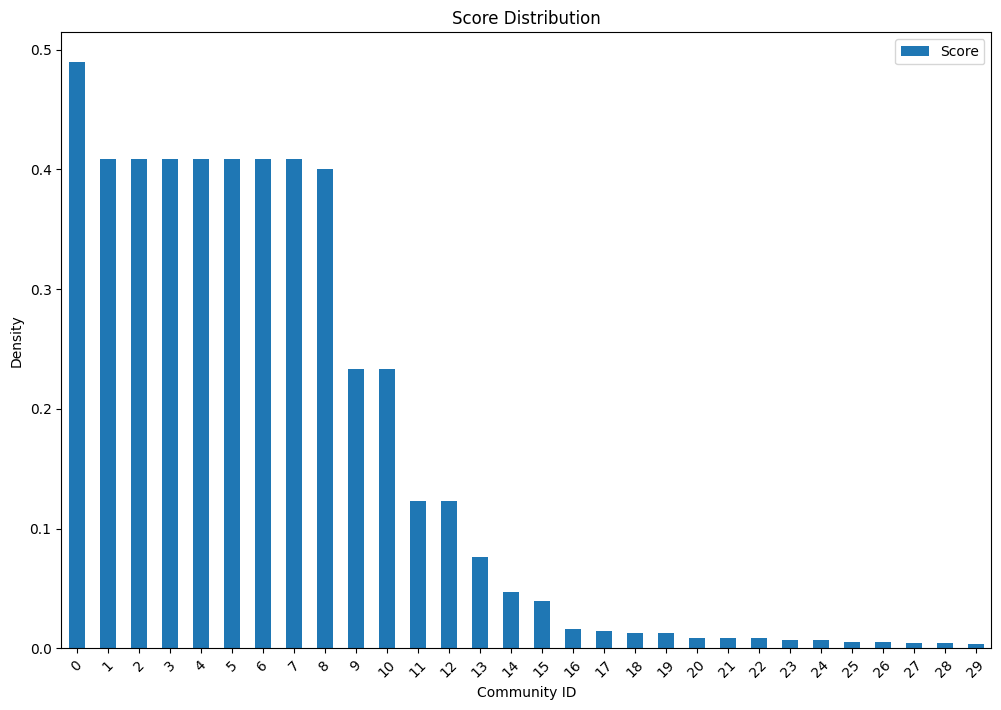

In [7]:
%matplotlib inline
rows = list(range(0, 30))
standard_plot(
    df_percentages, 
    type='bar', 
    rows=rows, 
    cols='Score', 
    title='Score Distribution', 
    x_label='Community ID', 
    y_label='Density'
)

#### Density Distribution

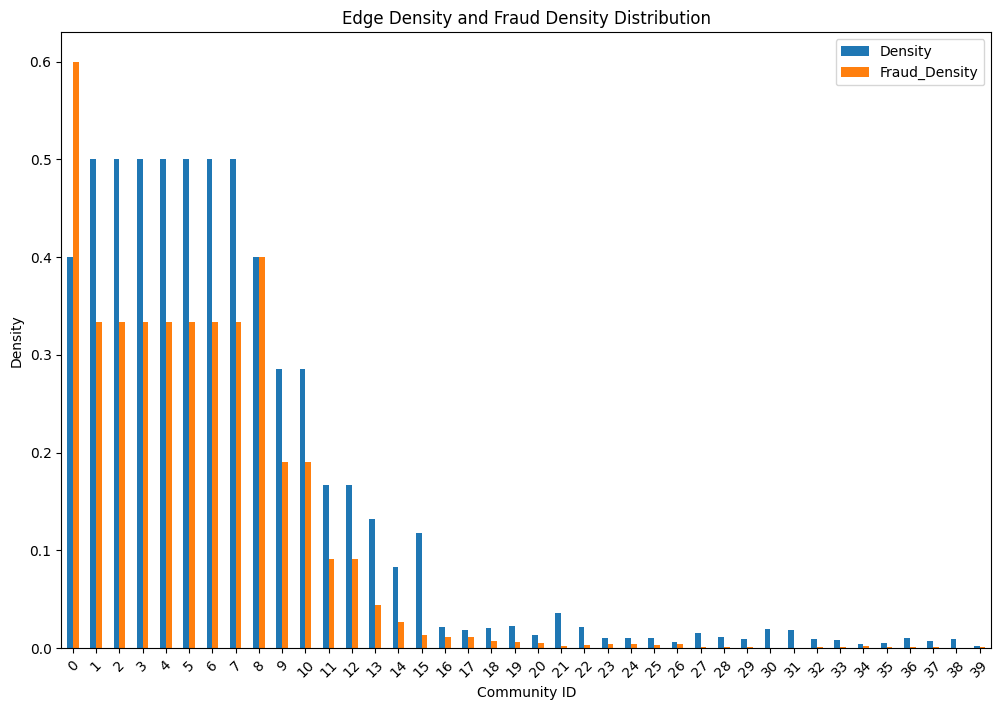

In [8]:
rows = list(range(0, 40))
standard_plot(
    df_percentages, 
    type='bar', 
    rows=rows, 
    cols='Density', 
    title='Edge Density and Fraud Density Distribution', 
    x_label='Community ID', 
    y_label='Density'
)

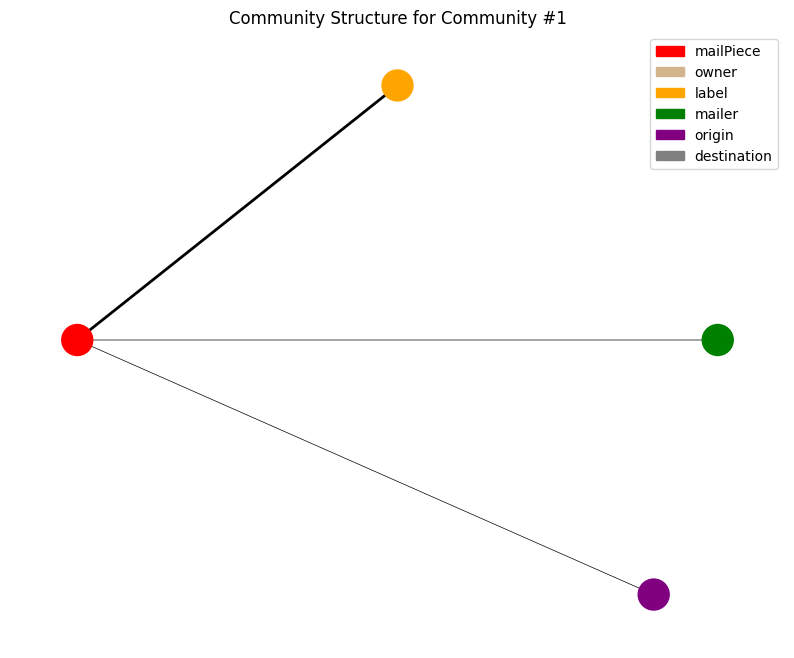

In [9]:
top_community = select_community(df_sorted, communities, 1)
sub_graph = make_subgraph(graph, top_community)
draw_single_community(sub_graph, top_community, 1)

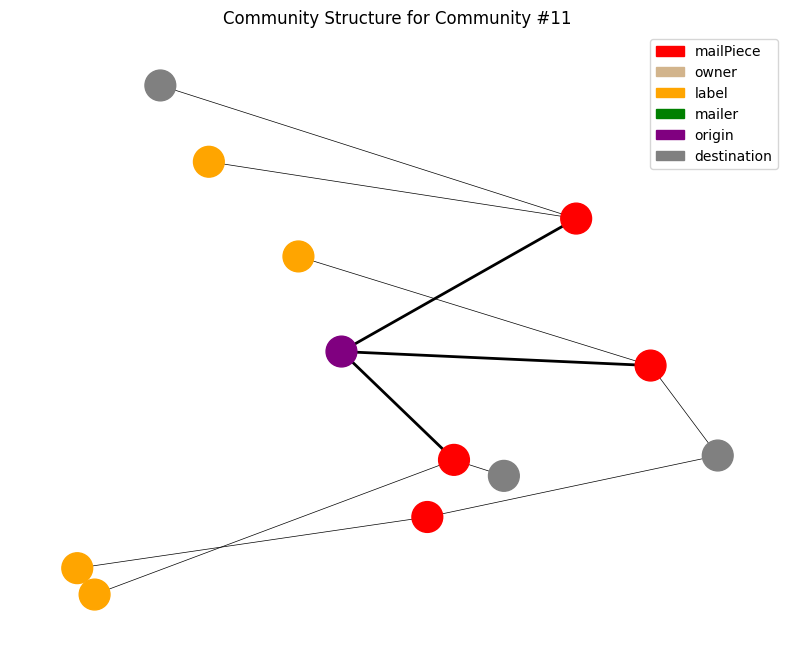

In [10]:
single_community = select_community(df_sorted, communities, 11)
sub_graph = make_subgraph(graph, single_community)
draw_single_community(sub_graph, single_community, 11)


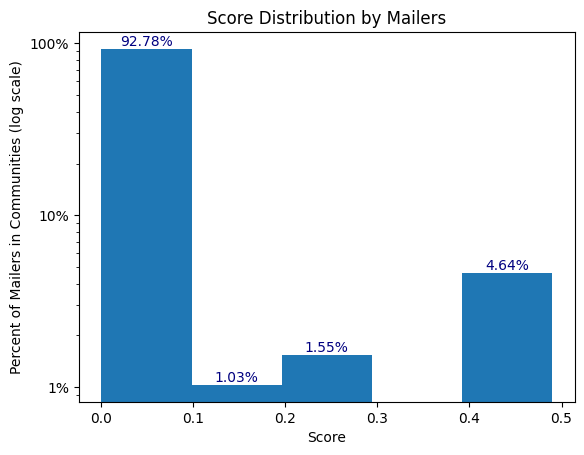

In [11]:
values, bins, bars = plt.hist(
    df_percentages.Score,
    weights=df_percentages.mailer_nodes / sum(df_percentages.mailer_nodes),
    log=True,
    bins=5,
)
plt.bar_label(bars, fontsize=10, color="navy", fmt="{:,.2%}")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Score Distribution by Mailers")
plt.xlabel("Score")
plt.ylabel("Percent of Mailers in Communities (log scale)")
plt.show()

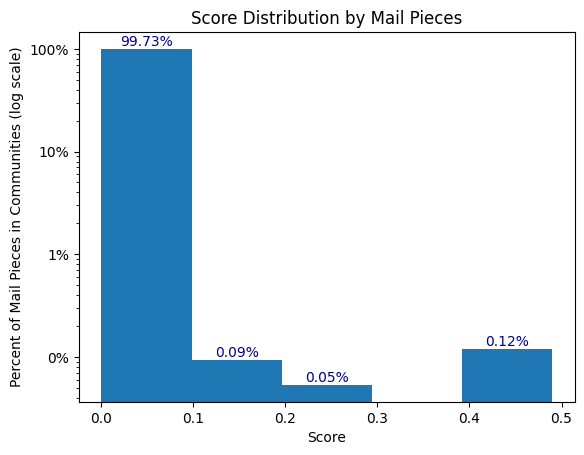

In [12]:
values, bins, bars = plt.hist(
    df_percentages.Score,
    weights=df_percentages.mailPiece_nodes / sum(df_percentages.mailPiece_nodes),
    log=True,
    bins=5,
)
plt.bar_label(bars, fontsize=10, color="navy", fmt="{:,.2%}")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Score Distribution by Mail Pieces")
plt.xlabel("Score")
plt.ylabel("Percent of Mail Pieces in Communities (log scale)")
plt.show()

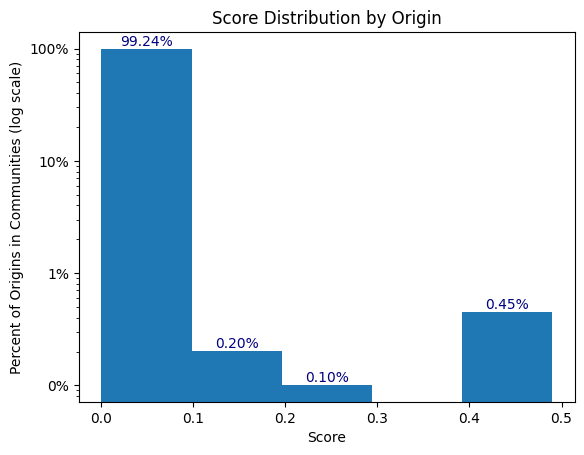

In [13]:
values, bins, bars = plt.hist(
    df_percentages.Score,
    weights=df_percentages.origin_nodes / sum(df_percentages.origin_nodes),
    log=True,
    bins=5,
)
plt.bar_label(bars, fontsize=10, color="navy", fmt="{:,.2%}")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Score Distribution by Origin")
plt.xlabel("Score")
plt.ylabel("Percent of Origins in Communities (log scale)")
plt.show()

#### Section 5: Example Downstream Process

1. Three mailPieces coming from the same origin had potential fraud indicators showing `firstzip_startzip_diff`.
    - The fraud indicators manifest as bold lines between nodes. 
2. Get the node ID for each of the mailPieces and query the properties of the associated nodes for their properties. 
3. Additionally, query to get the mailer and owner nodes that are associated with each of the potentially fraudulent mailPieces. 
4. Run comparison algorithms on the properties of MID and Owner nodes, and the mailPiece nodes to determine similarity and expose patterns. 
5. Make determination if further investigation is required to identify actual fraud. 